In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
from prophet import Prophet
from darts.models import VARIMA
from darts.models import ARIMA
from pmdarima.arima import auto_arima
from darts.models import Croston
from darts import TimeSeries

- darts에서 제공하는 ARIMA를 사용하자!

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_excel('../data/merged_data.xlsx')
df

,date,year,month,day,white,black,total
0,2023-08-01,2023,8,1,8,1,9
1,2023-08-02,2023,8,2,13,1,14
2,2023-08-03,2023,8,3,10,0,10
3,2023-08-04,2023,8,4,14,0,14
4,2023-08-05,2023,8,5,0,0,0
...,...,...,...,...,...,...,...
573,2025-02-24,2025,2,24,2,23,25
574,2025-02-25,2025,2,25,2,11,13
575,2025-02-26,2025,2,26,0,6,6
576,2025-02-27,2025,2,27,0,4,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    578 non-null    datetime64[ns]
 1   year    578 non-null    int64         
 2   month   578 non-null    int64         
 3   day     578 non-null    int64         
 4   white   578 non-null    int64         
 5   black   578 non-null    int64         
 6   total   578 non-null    int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 31.7 KB


***

# EDA

In [7]:
def plot_separate_time_series(df, cols):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(3, 1, i)
        plt.plot(df['date'], df[col], label=col, color='tab:blue')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title(f'{col} over time')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

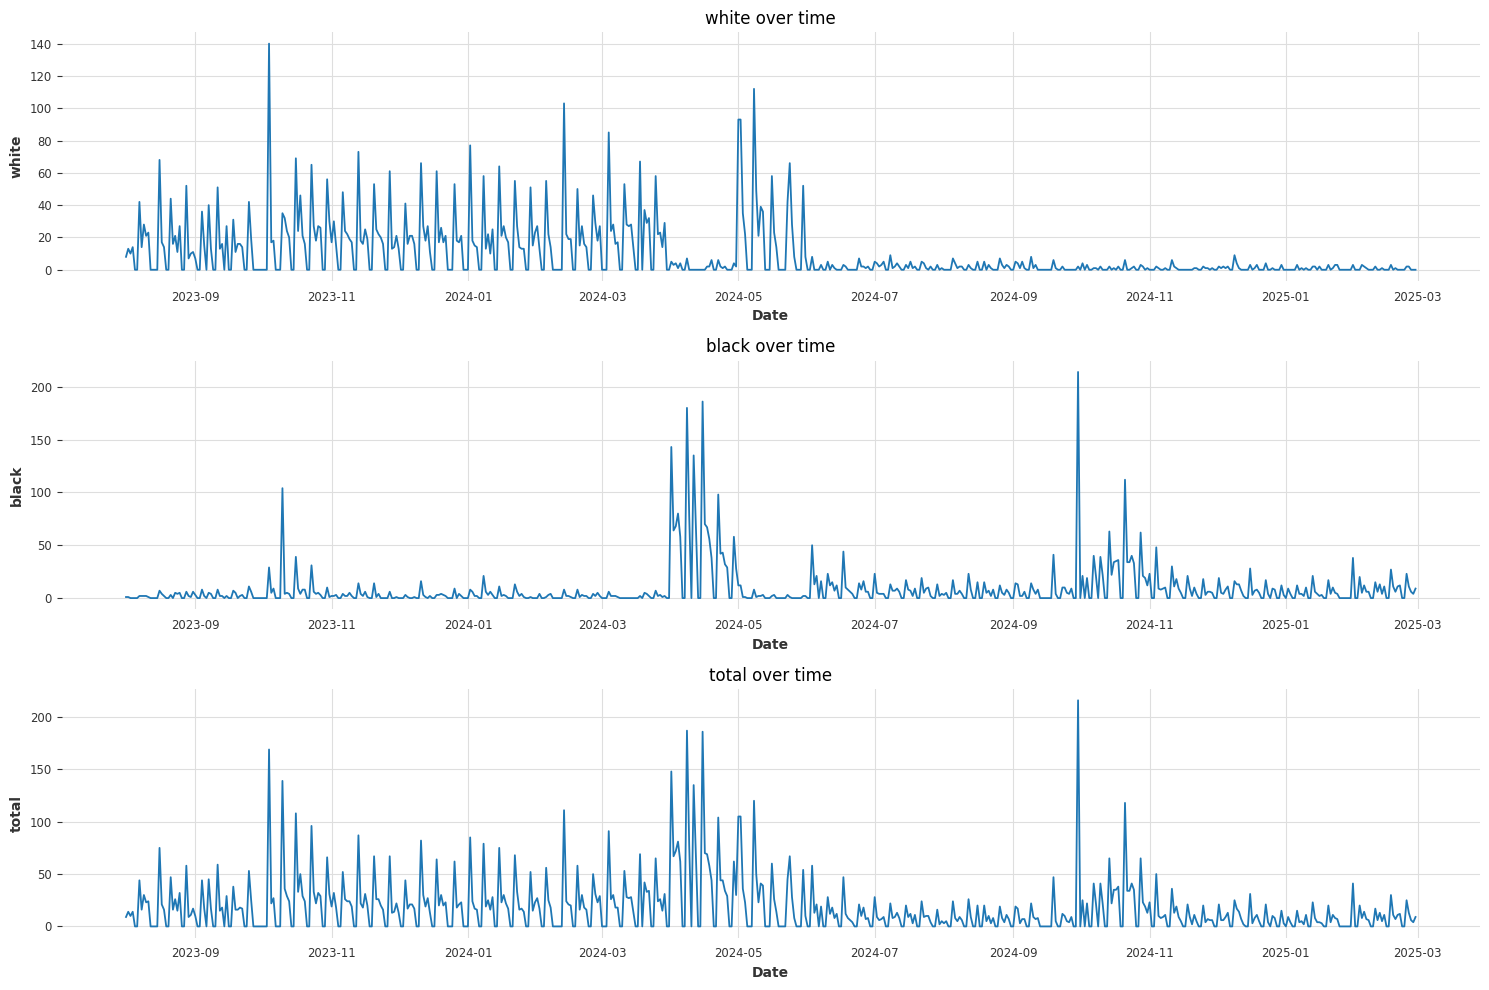

In [8]:
# 실행
plot_separate_time_series(df, ['white', 'black', 'total'])

***

# Auto_ARIMA

1. 맨 처음에 실행된 auto_arima에서 찾은 p,d,q를 설정하여 이후는 ARIMA를 실행함

In [11]:
def sliding_arima_forecast_darts(df, col, test_ratio=0.2, window_size=7):
    df = df.set_index('date')
    series = df[col].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # (1) auto_arima로 p,d,q 탐색 (pmdarima 사용)
    model_init = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
    p, d, q = model_init.order
    print(f"[{col}] 고정된 ARIMA Order: ({p},{d},{q})")

    preds = []

    # Darts용 TimeSeries로 변환
    full_series = TimeSeries.from_series(series)
    train_ts = full_series[:split_idx]
    test_ts = full_series[split_idx:]

    # 슬라이딩 예측
    history = train_ts
    for i in range(0, len(test_ts), window_size):
        end_idx = min(i + window_size, len(test_ts))

        model = ARIMA(p=p, d=d, q=q)
        model.fit(history)

        forecast = model.predict(end_idx - i)
        preds.append(forecast)

        # history 업데이트
        history = history.append(test_ts[i:end_idx])

    # 전체 예측 연결
    forecast_series = preds[0]
    for f in preds[1:]:
        forecast_series = forecast_series.append(f)

    # 시각화
    plt.figure(figsize=(12, 5))
    test_ts.plot(label='Actual', color='black')
    forecast_series.plot(label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (Darts)')
    plt.legend()
    plt.grid(True)
    plt.show()

[white] 고정된 ARIMA Order: (2,1,3)


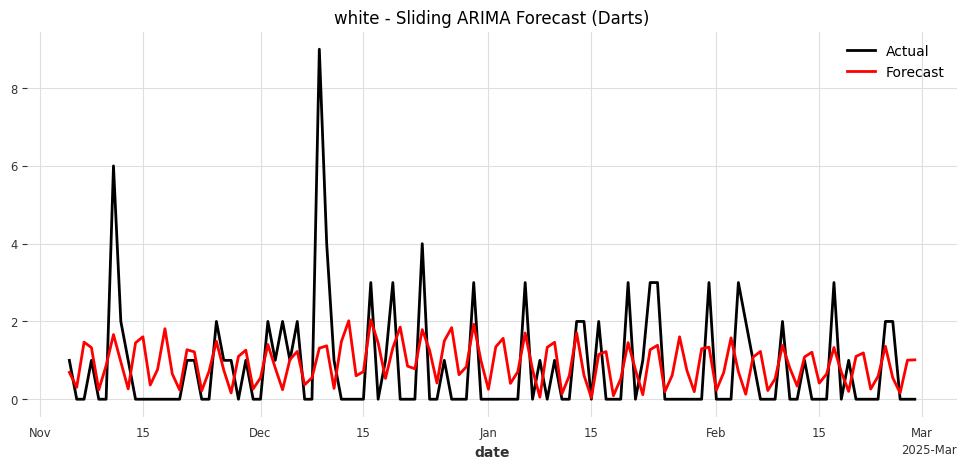

[black] 고정된 ARIMA Order: (2,1,1)


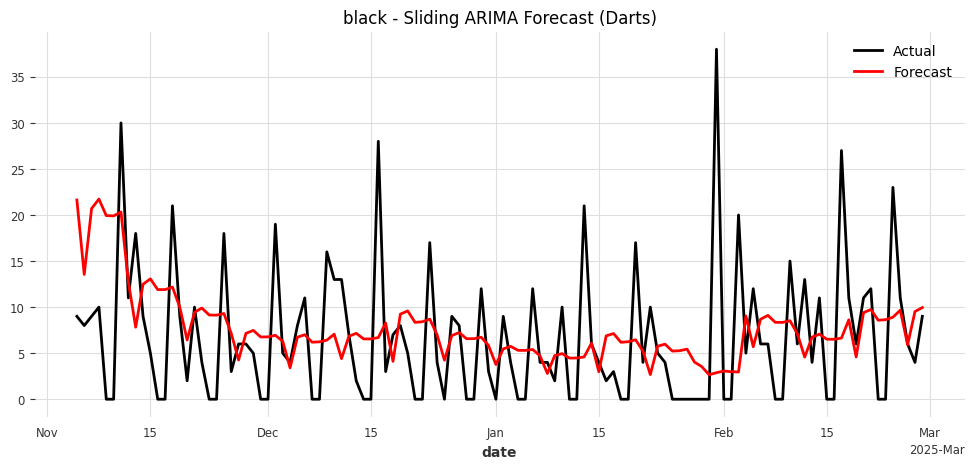

[total] 고정된 ARIMA Order: (5,1,5)


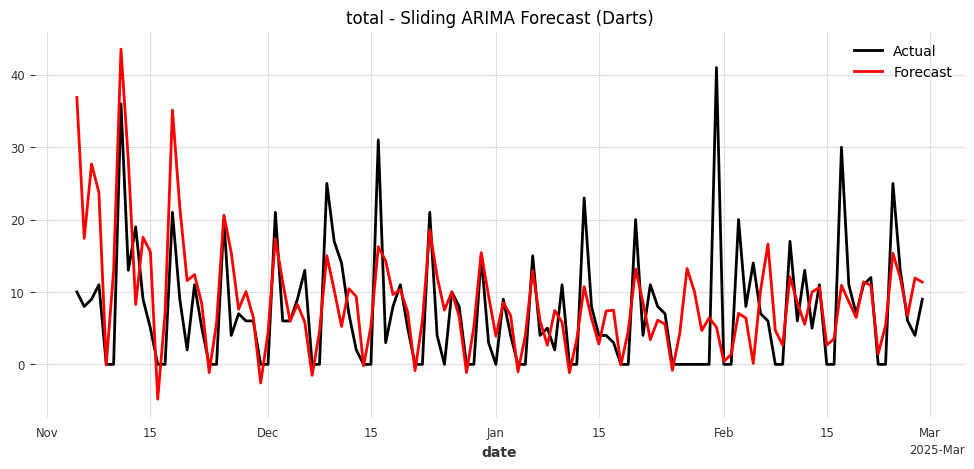

In [12]:
# white, black 컬럼에 대해 반복 실행
for col in ['white', 'black', 'total']:
    sliding_arima_forecast_darts(df, col)

2) 초기에 p,d,q를 설정하지 않고 7일(= window_size)마다 새롭게 auto_arima를 돌려서 가장 좋은 (p,d,q) 조합을 찾아서 예측에 사용

In [20]:
def sliding_arima_forecast_dynamic(df, col, test_ratio=0.2, window_size=3):
    df = df.set_index('date')
    series = df[col].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    preds = []

    # TimeSeries로 변환
    full_series = TimeSeries.from_series(series)
    train_ts = full_series[:split_idx]
    test_ts = full_series[split_idx:]

    # 슬라이딩 예측 시작
    history = train_ts

    for i in range(0, len(test_ts), window_size):
        end_idx = min(i + window_size, len(test_ts))

        # (1) 매 슬라이딩마다 p,d,q 재탐색
        # 수정된 코드
        history_pd = pd.Series(
            data=history.values().flatten(),
            index=history.time_index
        )
        
        model_init = auto_arima(history_pd, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
        p, d, q = model_init.order
        print(f"[{col}] {history.end_time().date()}까지 학습한 ARIMA Order: ({p},{d},{q})")

        # (2) darts ARIMA 모델 학습 및 예측
        model = ARIMA(p=p, d=d, q=q)
        model.fit(history)
        forecast = model.predict(end_idx - i)

        preds.append(forecast)

        # history 업데이트
        history = history.append(test_ts[i:end_idx])

    # 전체 예측 연결
    forecast_series = preds[0]
    for f in preds[1:]:
        forecast_series = forecast_series.append(f)

    # 시각화
    plt.figure(figsize=(12, 5))
    test_ts.plot(label='Actual', color='black')
    forecast_series.plot(label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (Dynamic Order)')
    plt.legend()
    plt.grid(True)
    plt.show()

[white] 2024-11-04까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-07까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-10까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-13까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-16까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-19까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-22까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-25까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-28까지 학습한 ARIMA Order: (0,1,4)
[white] 2024-12-01까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-04까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-07까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-10까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-13까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-16까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-19까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-22까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-25까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-28까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-31까지 학습한 ARIMA Order: (2,1,3)
[white] 2025-01-03까지 학습한 ARIMA Order: (3,1,2)
[white] 2025-01-06까지 학습한 ARIMA Ord

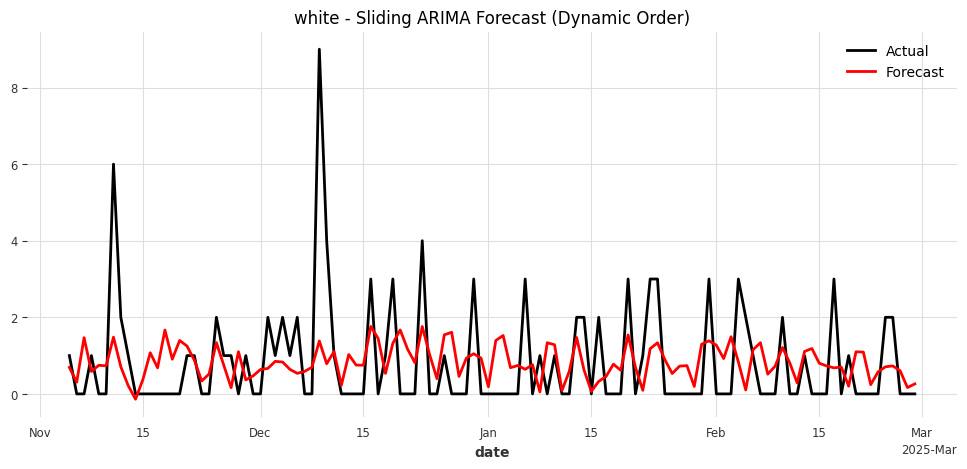

[black] 2024-11-04까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-07까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-10까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-13까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-16까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-19까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-22까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-25까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-28까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-01까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-04까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-07까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-10까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-13까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-16까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-19까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-22까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-25까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-28까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-31까지 학습한 ARIMA Order: (2,1,1)
[black] 2025-01-03까지 학습한 ARIMA Order: (2,1,1)
[black] 2025-01-06까지 학습한 ARIMA Ord

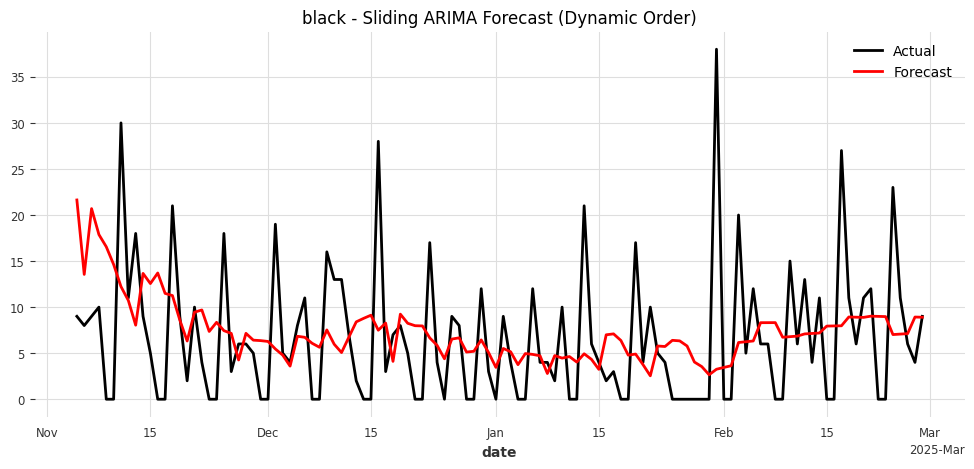

[total] 2024-11-04까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-07까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-10까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-13까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-16까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-19까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-22까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-25까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-28까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-01까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-04까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-07까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-10까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-13까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-16까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-19까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-22까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-25까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-28까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-31까지 학습한 ARIMA Order: (5,1,5)
[total] 2025-01-03까지 학습한 ARIMA Order: (5,1,5)
[total] 2025-01-06까지 학습한 ARIMA Ord

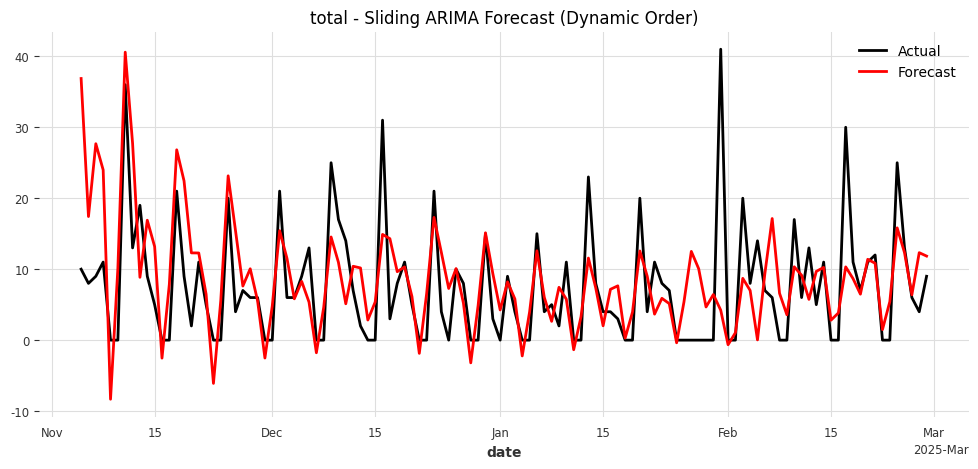

In [21]:
# 대상 컬럼별 반복 예측
target_cols = ['white', 'black', 'total']
for col in target_cols:
    sliding_arima_forecast_dynamic(df, col)

***

# Prophet

In [13]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['date', col]].copy()
    series.columns = ['ds', 'y']  # Prophet에 맞는 컬럼명

    # ✅ 결측치 0으로 채움 (간헐적 수요 반영)
    series['y'] = series['y'].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # Prophet 모델 학습
    model = Prophet()
    model.fit(train)

    # 미래 데이터프레임 생성
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    # 예측값 추출
    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]

    # ✅ 음수 예측값을 0으로 수정 - relu
    pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast (Adjusted)', color='red')
    plt.title(f'{col} - Prophet Forecast (No Negative Values)')
    plt.legend()
    plt.grid(True)
    plt.show()

14:31:26 - cmdstanpy - INFO - Chain [1] start processing
14:31:27 - cmdstanpy - INFO - Chain [1] done processing


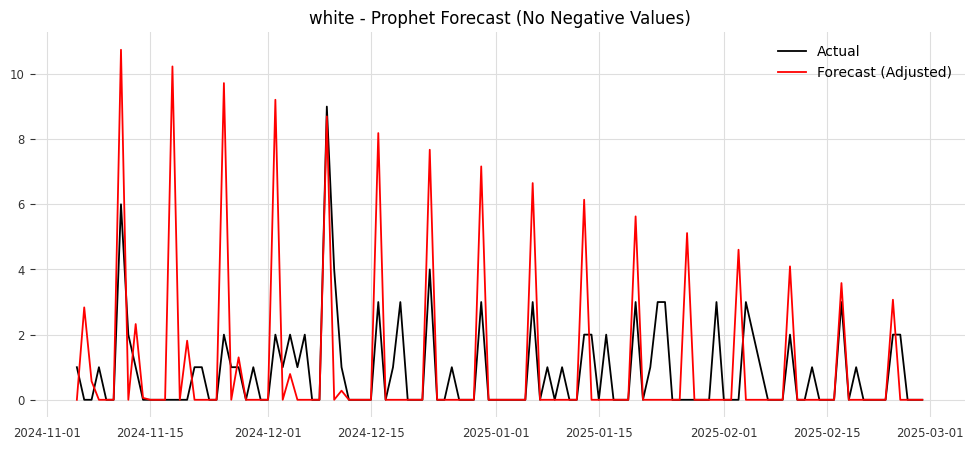

14:31:28 - cmdstanpy - INFO - Chain [1] start processing
14:31:28 - cmdstanpy - INFO - Chain [1] done processing


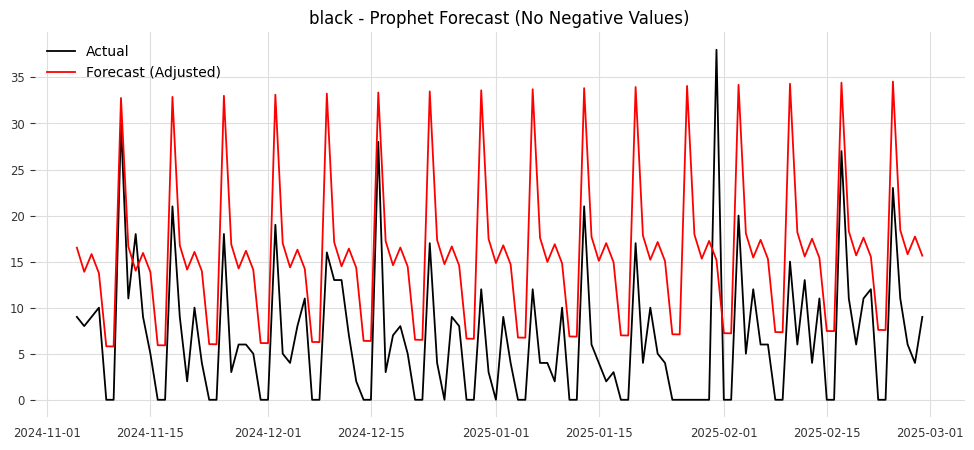

14:31:28 - cmdstanpy - INFO - Chain [1] start processing
14:31:28 - cmdstanpy - INFO - Chain [1] done processing


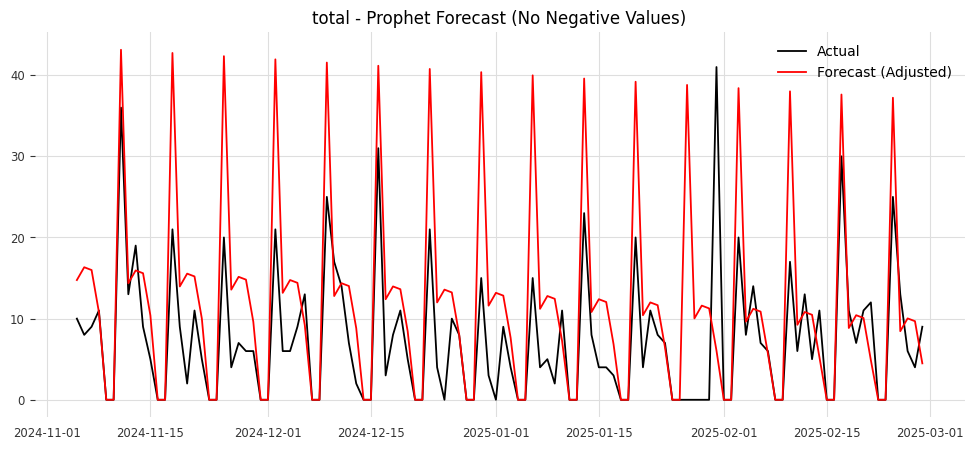

In [14]:
# 실행
target_cols = ['white', 'black', 'total']
for col in target_cols:
    prophet_forecast(df.copy(), col)

***

# Croston

In [15]:
def croston_forecast(df, col, test_ratio=0.2):
    # ✅ 중복 날짜를 평균으로 집계 + 결측치 0으로 대체
    series = (
        df[['date', col]]
        .groupby('date', as_index=False)
        .mean()
        .fillna({col: 0})
    )

    # TimeSeries 생성
    ts = TimeSeries.from_dataframe(
        series,
        time_col='date',
        value_cols=col,
        fill_missing_dates=True,
        freq='D'
    )

    # Train/Test split
    split_idx = int(len(ts) * (1 - test_ratio))
    train, test = ts[:split_idx], ts[split_idx:]

    # Croston 모델 학습 및 예측
    model = Croston()
    model.fit(train)
    forecast = model.predict(len(test))

    # 시각화
    plt.figure(figsize=(12, 5))
    test.plot(label='Actual', color='black')
    forecast.plot(label='Forecast', color='red')
    plt.title(f'{col} - Croston Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

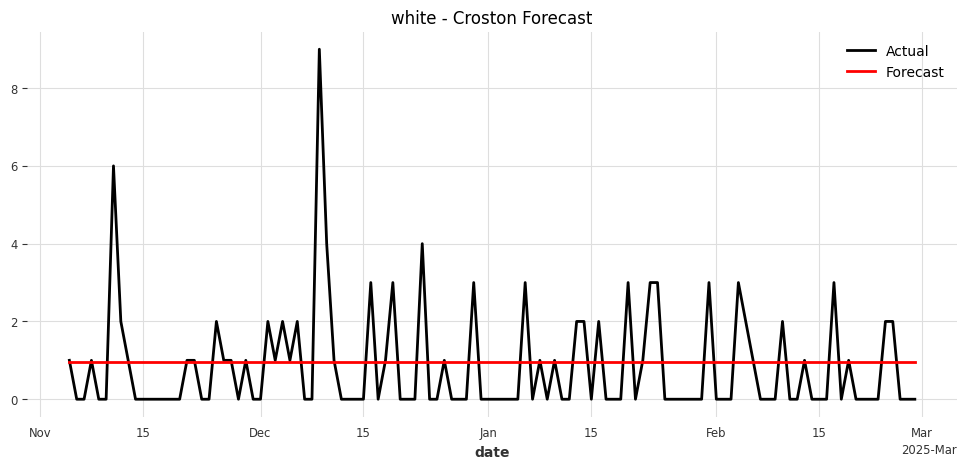

In [16]:
croston_forecast(df, 'white')

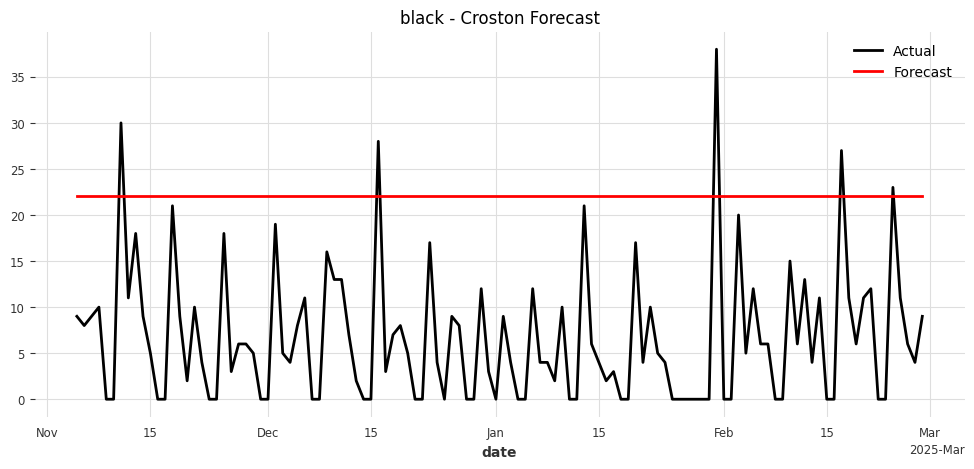

In [17]:
croston_forecast(df, 'black')

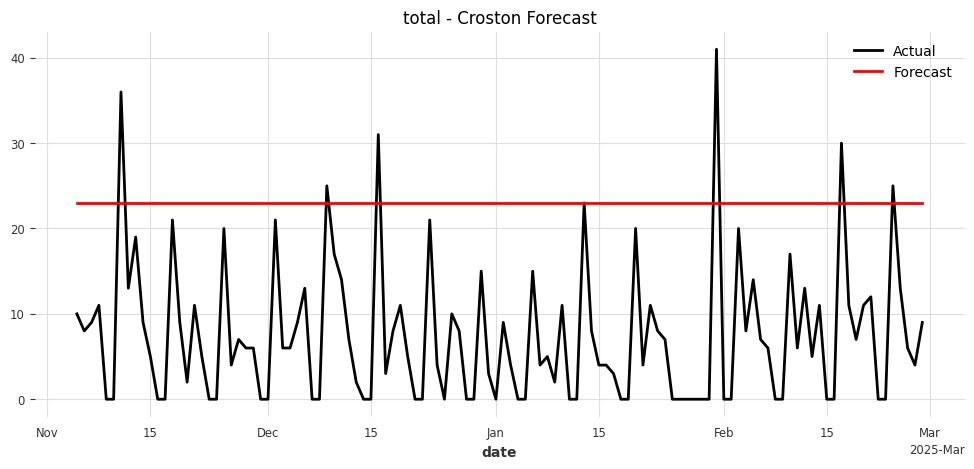

In [18]:
croston_forecast(df, 'total')

***

# VARIMA (다변량 시계열: 변수 간 상관성 반영)

In [19]:
def varima_forecast_sliding(df, cols, test_ratio=0.2, sliding_window=3):
    df = df[['date'] + cols].dropna().drop_duplicates(subset='date')
    df = df.set_index('date').asfreq('D')
    df = df.fillna(0)

    series = TimeSeries.from_dataframe(df)
    
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    history = train
    forecasts = []

    model = VARIMA(2,1,2) # 초기 모델 fit
    model.fit(history)

    for i in range(0, len(test), sliding_window):
        n_predict = min(sliding_window, len(test) - i)

        forecast = model.predict(n_predict)
        forecasts.append(forecast)

        # update: 예측 끝난 부분까지 실제 test data를 추가
        history = history.append(test[i:i+n_predict])

        # 모델 재학습 (원래 VARIMA는 incremental learning이 어려워서 다시 fit)
        model = VARIMA(2,1,2)
        model.fit(history)

    # 모든 작은 forecasts를 이어붙임
    forecast_all = forecasts[0]
    for f in forecasts[1:]:
        forecast_all = forecast_all.append(f)

    # 시각화
    for col in cols:
        plt.figure(figsize=(12, 5))
        test[col].plot(label='Actual', color='black')
        forecast_all[col].plot(label='Sliding VARIMA Forecast', color='red')
        plt.title(f'{col} - VARIMA Sliding Forecast')
        plt.legend()
        plt.grid(True)
        plt.show()

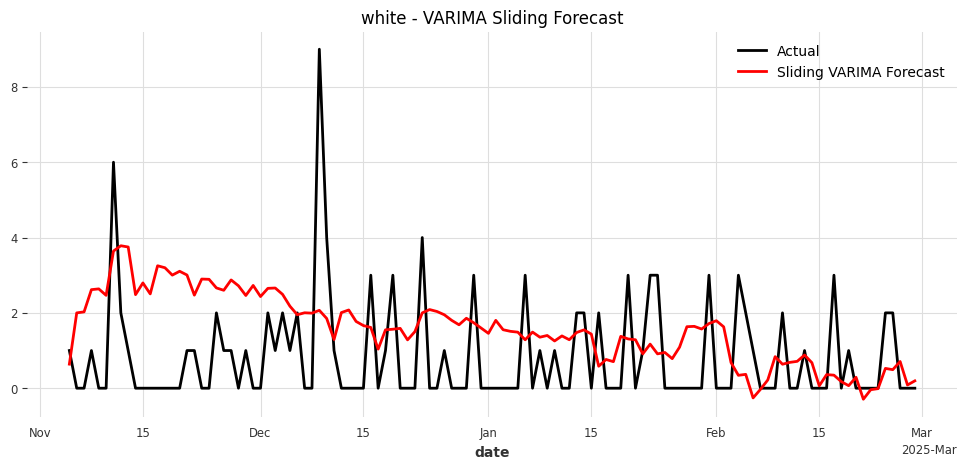

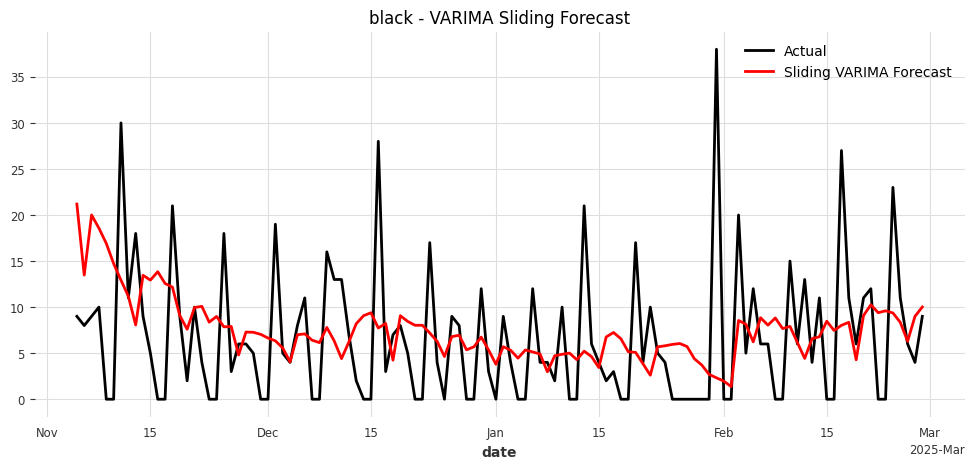

In [20]:
varima_forecast_sliding(df, ['white', 'black'])